In [ ]:
import numpy as np
import pandas as pd

from estimator import TreatmentEffectEstimator

In [80]:
# -----------------------
# Simulate panel data
# -----------------------
np.random.seed(0)

n_units = 50
n_periods = 10

units = np.repeat(np.arange(n_units), n_periods)
times = np.tile(np.arange(n_periods), n_units)

x1 = np.random.normal(size=n_units * n_periods)
x2 = np.random.normal(size=n_units * n_periods)

# Binary treatment with staggered adoption
treat = (times >= 5).astype(int)

# True heterogeneous effect
true_tau = np.where(x1 > 0, 2.0, 0.5) #+ np.random.normal(0, 0.2, size=len(x1))

# Rank-one baseline: unit effect × time effect
unit_effect = np.random.normal(size=n_units)
time_effect = np.random.normal(size=n_periods)
baseline = (np.outer(unit_effect, time_effect)).ravel()

# Outcome
y = 10 + baseline + true_tau * treat
    

df = pd.DataFrame({
    "unit": units,
    "time": times,
    "y": y,
    "x1": x1,
    "x2": x2,
    "treatA": treat,
})

df

,unit,time,y,x1,x2,treatA
0,0,0,9.599740,1.764052,0.382732,0
1,0,1,9.503206,0.400157,-0.034242,0
2,0,2,9.913257,0.978738,1.096347,0
3,0,3,10.583257,2.240893,-0.234216,0
4,0,4,11.762944,1.867558,-0.347451,0
...,...,...,...,...,...,...
495,49,5,10.338137,-0.073925,0.412871,1
496,49,6,11.651762,-0.658553,-0.198399,1
497,49,7,9.419500,-0.514234,0.094192,1
498,49,8,10.756918,-1.018042,-1.147611,1


In [81]:
# -----------------------
# Fit PaCE
# -----------------------
est = TreatmentEffectEstimator(
    data=df,
    column_unit="unit",
    column_time="time",
    column_outcome="y",
    columns_for_X=["x1", "x2"],
    columns_for_Z=["treatA"],
    suggest_r=1,
)

est.fit(max_leaves=5)

print("Estimated ATE:", est.ate)



0
1
2
3
Estimated ATE: [1.2289625856555864]


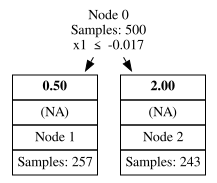

Tree visualization saved as: example_tree.pdf


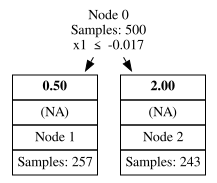

In [82]:
# -----------------------
# Visualization
# -----------------------
from visualization import visualize_treatment_effect
visualize_treatment_effect(est, filename="example_tree")
